In [186]:
!pip install scikit-learn seaborn matplotlib


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [187]:
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn import tree
import pandas as pd

import duckdb as dd

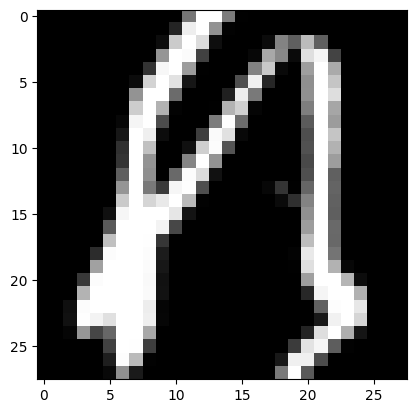

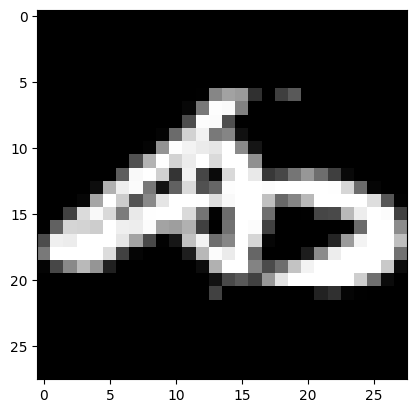

In [188]:
carpeta = 'Archivos/'
map_caracters =  pd.read_csv(carpeta + 'kuzushiji_full.csv')
class_caracters =  pd.read_csv(carpeta + 'kmnist_classmap_char.csv')

list_columns =  []
# Estoy colocando las columnas con los nombres pixel_i
for i in range(784):
    list_columns.append(f'pixel_{i+1}')
list_columns.append('label')
map_caracters.columns = list_columns


X = map_caracters.copy()
for i in range(2):
    img = np.array(X.iloc[i][:-1]).reshape((28,28))
    plt.imshow(img, cmap='gray')
    plt.show()


    

# Analisis de los datos Ej1:


2. DISTRIBUCIÓN DE CLASES


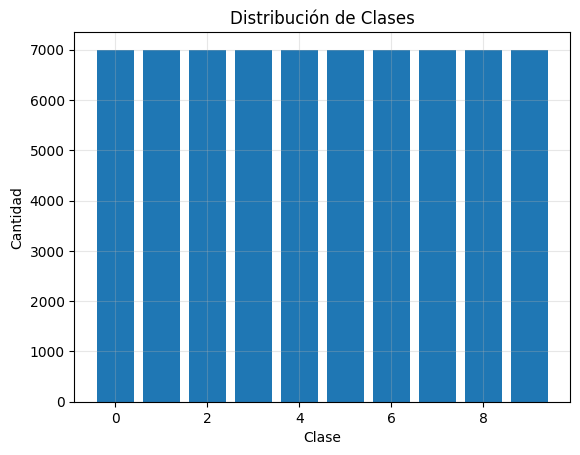

In [189]:

print("\n2. DISTRIBUCIÓN DE CLASES")
y = X['label']
distribucion_clases = y.value_counts().sort_index()


plt.bar(distribucion_clases.index, distribucion_clases.values)
plt.xlabel('Clase')
plt.ylabel('Cantidad')
plt.title('Distribución de Clases')
plt.grid(True, alpha=0.3)

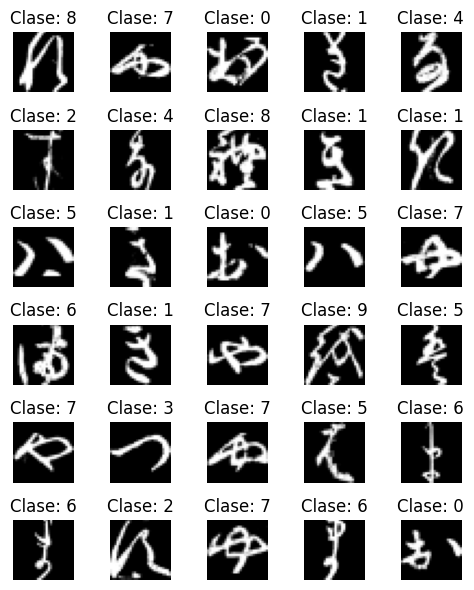

In [190]:
# Visualizar en grid de 3x3
filas = 6
columnas = 5

fig, axes = plt.subplots(filas, columnas, figsize=(columnas, filas))

for i in range(filas * columnas):
    if i < len(X):
        fila = i // columnas
        col = i % columnas
        
        img = np.array(X.iloc[i][:-1]).reshape((28, 28))
        label = X.iloc[i]['label']
        
        axes[fila, col].imshow(img, cmap='gray')
        axes[fila, col].set_title(f'Clase: {label}')
        axes[fila, col].axis('off')

plt.tight_layout()
plt.show()


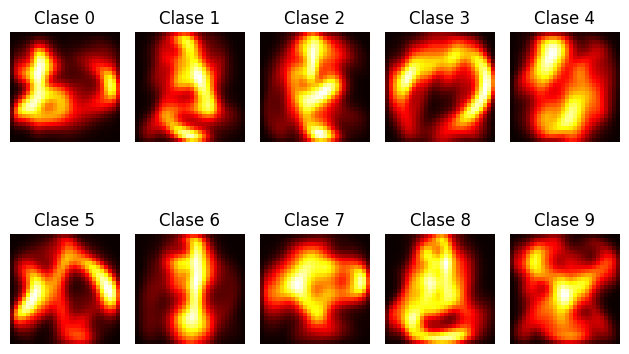

In [217]:
x = X.drop('label', axis = 1).values
y = X['label'].values

for j in range(10):
    mean_img =  x[y==j].mean(axis = 0).reshape(28,28)
    plt.subplot(2,5,j+1)
    plt.imshow(mean_img,cmap = 'hot')
    plt.title(f'Clase {j}')
    plt.axis('off')

plt.tight_layout()


(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

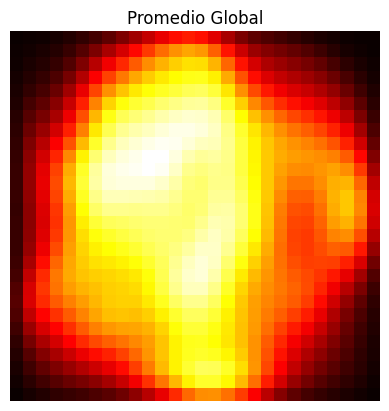

In [218]:
# Esto promedia TODAS las imágenes juntas
mean_global = x.mean(axis=0).reshape(28,28)  # ← Promedio de todo el dataset
plt.imshow(mean_global,cmap = 'hot')
plt.title(f'Promedio Global')
plt.axis('off') 

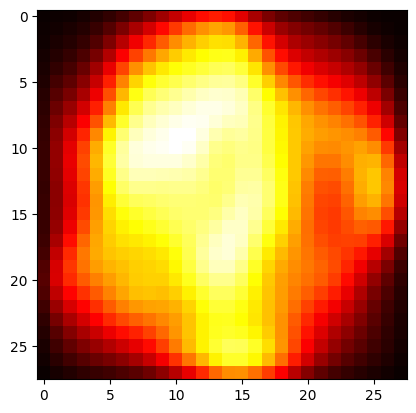

In [ ]:

def reshapear_imagen(img, n):
    if n == 0:
        return img
    else:
        img_2 =  img[n:-n]
        img_3 = np.array([fila[n:-n] for fila in img_2])
        return img_3
X = map_caracters.copy()

for i in range(1):
    mean_global = x.mean(axis=0).reshape(28,28)
    mean_global = reshapear_imagen(mean_global, 0)
    plt.imshow(mean_global, cmap='hot')
    plt.show()


# Analisis 2

In [194]:
from sklearn.metrics import accuracy_score, precision_score, recall_score , classification_report, confusion_matrix 
from sklearn.neighbors import KNeighborsClassifier
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# =============================================================================
# FUNCIONES
# =============================================================================

def generar_puntos_logaritmicos(inicio=1, fin=100, num_puntos=50, base=10):
    """
    Genera puntos distribuidos logarítmicamente (más densos al inicio)
    """
    log_inicio = np.log(inicio) / np.log(base)
    log_fin = np.log(fin) / np.log(base)
    
    puntos_log = np.linspace(log_inicio, log_fin, num_puntos)
    puntos = base ** puntos_log
    puntos_enteros = np.unique(np.round(puntos).astype(int))
    
    return puntos_enteros[(puntos_enteros >= inicio) & (puntos_enteros <= fin)]

def evaluar_modelo(X_train, X_test, y_train, y_test, n_atributos, n_vecinos=10):
    """
    Evalúa un modelo KNN con un número específico de atributos
    """
    # Seleccionar atributos aleatorios
    X_train_n = X_train.sample(n=n_atributos, axis=1)
    atributos_seleccionados = [col for col in X_train_n if col in X_train]
    X_test_n = X_test[atributos_seleccionados]

    # Entrenar y predecir
    clasificador = KNeighborsClassifier(n_neighbors=n_vecinos)
    clasificador.fit(X_train_n, y_train)
    y_pred = clasificador.predict(X_test_n)
    
    # Calcular métricas
    precision_4 = precision_score(pos_label=4, y_true=y_test, y_pred=y_pred)
    precision_5 = precision_score(pos_label=5, y_true=y_test, y_pred=y_pred)
    recall_4 = recall_score(pos_label=4, y_true=y_test, y_pred=y_pred)
    recall_5 = recall_score(pos_label=5, y_true=y_test, y_pred=y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    
    return precision_4, precision_5, recall_4, recall_5, accuracy

def ejecutar_n_atributos(X_train, X_test, y_train, y_test, array_n_pixeles, k_vecinos=10, repeticiones_estadisticas=2):

    """
    Ejecuta una selección de atributos para KNN evaluando diferentes cantidades de píxeles.
    
    Input: 
    ----------
    X_train : pandas.DataFrame
        DataFrame con los features de entrenamiento (píxeles de imágenes)
    X_test : pandas.DataFrame  
        DataFrame con los features de test (píxeles de imágenes)
    y_train : pandas.Series
        Series con las etiquetas de entrenamiento (clases 4 y 5)
    y_test : pandas.Series
        Series con las etiquetas de test (clases 4 y 5)
    array_n_pixeles : array-like
        Array con los números de píxeles a probar (ej: [1, 5, 10, 20, 50])
    k_vecinos : int, optional
        Número de vecinos para KNeighborsClassifier, por defecto 10
    repeticiones_estadisticas : int, optional
        Número de repeticiones por configuración para robustez estadística, por defecto 2
    
    Returns
    -------
    tuple (pandas.DataFrame, dict)
        DataFrame con las métricas de evaluación para cada configuración probada.
        Diccionario con matrices de confusión y predicciones de la última repetición.
        
        DataFrame columns:
        - presicion_4: Precision promedio para la clase 4
        - precision_5: Precision promedio para la clase 5  
        - recall_4: Recall promedio para la clase 4
        - recall_5: Recall promedio para la clase 5
        - accuracy: Accuracy promedio global
        - n_atributos: Número de píxeles probado
        
        Dict structure:
        - key: n_pixeles (int)
        - value: dict con:
            * 'matriz_confusion': array 2x2
            * 'matriz_normalizada': array 2x2 (normalizada por filas)
            * 'y_pred': array de predicciones
            
    Notes
    -----
    - Los píxeles son seleccionados aleatoriamente en cada repetición
    - Las métricas son promediadas sobre las repeticiones
    - Utiliza KNeighborsClassifier con el número de vecinos especificado
    - Está optimizado para clasificación binaria entre clases 4 y 5
    """
    
    report_list = []
    matrices_confusion = {} 
    
    # Bucle principal de experimentación
    for n in tqdm(array_n_pixeles, desc="Atributos", unit="config"):
        pres_4, pres_5, re_4, re_5, acc_rep = [], [], [], [], []
        
        # Repeticiones para robustez estadística
        for rep in tqdm(range(repeticiones_estadisticas), desc=f"n={n}", leave=False, unit="rep"):
            # Seleccionar atributos
            X_train_n = X_train.sample(n=n, axis=1)
            atributos_seleccionados = X_train_n.columns.tolist()
            X_test_n = X_test[atributos_seleccionados]

            # Entrenar y predecir
            clasificador = KNeighborsClassifier(n_neighbors=k_vecinos)
            clasificador.fit(X_train_n, y_train)
            y_pred = clasificador.predict(X_test_n)
            
            # Calcular métricas
            precision_4 = precision_score(pos_label=4, y_true=y_test, y_pred=y_pred)
            precision_5 = precision_score(pos_label=5, y_true=y_test, y_pred=y_pred)
            recall_4 = recall_score(pos_label=4, y_true=y_test, y_pred=y_pred)
            recall_5 = recall_score(pos_label=5, y_true=y_test, y_pred=y_pred)
            acc = accuracy_score(y_test, y_pred)

            pres_4.append(precision_4)
            pres_5.append(precision_5)
            re_4.append(recall_4)
            re_5.append(recall_5)
            acc_rep.append(acc)
            
            
            if rep == repeticiones_estadisticas - 1:
                matriz = confusion_matrix(y_test, y_pred)
                matriz_norm = confusion_matrix(y_test, y_pred, normalize='true')
                
                matrices_confusion[int(n)] = {
                    'matriz_confusion': matriz,
                    'matriz_normalizada': matriz_norm,
                    'y_pred': y_pred
                }
        

        report = {
            'presicion_4': np.average(pres_4),
            'precision_5': np.average(pres_5),
            'recall_4': np.average(re_4),
            'recall_5': np.average(re_5),
            'accuracy': np.average(acc_rep),
            'n_atributos': n
        }
        report_list.append(report)

    
    df_results = pd.DataFrame(report_list)
    return df_results, matrices_confusion 

def entrenar_con_recortes(X_train, X_test, y_train, y_test, tamanos_recorte, num_vecinos=10):

    
    """
    Entrena modelos KNN con imágenes recortadas a diferentes tamaños
    
    Parameters
    ----------
    X_train, X_test : DataFrames con features (píxeles)
    y_train, y_test : Series con labels
    tamanos_recorte : list of int
        Lista de píxeles a recortar de cada borde (ej: [0, 1, 2, 3, 4])
    num_vecinos : int
        Número de vecinos para KNN
    
    Returns
    -------
    pandas.DataFrame con resultados para cada tamaño de recorte
    """
    resultados_recortes = []
    
    for n_recorte in tqdm(tamanos_recorte, desc="Tamaños recorte"):
        # Calcular tamaño final después del recorte
        tamaño_final = 28 - 2 * n_recorte
        total_pixeles = tamaño_final * tamaño_final
        
        # Calcular índices de píxeles a mantener
        indices_keep = []
        for i in range(28):
            for j in range(28):
                if n_recorte <= i < 28 - n_recorte and n_recorte <= j < 28 - n_recorte:
                    indices_keep.append(i * 28 + j)
        
        # Seleccionar solo los píxeles del área central (sin bordes)
        X_train_recortado = X_train.iloc[:, indices_keep]
        X_test_recortado = X_test.iloc[:, indices_keep]
        
        # REUTILIZAR evaluar_modelo - ahora n_atributos = total_pixeles (todos los píxeles centrales)
        precision_4, precision_5, recall_4, recall_5, accuracy = evaluar_modelo(
            X_train_recortado, X_test_recortado, y_train, y_test, 
            n_atributos=total_pixeles,  # Usamos TODOS los píxeles del área central
            n_vecinos=num_vecinos
        )
        
        resultados_recortes.append({
            'recorte_bordes': n_recorte,
            'tamaño_imagen': f"{tamaño_final}x{tamaño_final}",
            'total_pixeles': total_pixeles,
            'accuracy': accuracy,
            'precision_4': precision_4,
            'precision_5': precision_5,
            'recall_4': recall_4,
            'recall_5': recall_5,
            'indices_keep': indices_keep  # Para uso posterior
        })
    
    return pd.DataFrame(resultados_recortes)

def extraer_bordes_como_features(img, n):
    """
    Extrae solo los píxeles de los bordes y los devuelve como vector 1D
    
    Parameters
    ----------
    img : numpy.array
        Imagen 2D de entrada (28x28)
    n : int
        Grosor del borde a extraer (píxeles)
    
    Returns
    -------
    numpy.array
        Vector 1D con solo los píxeles de los bordes
    """
    if n == 0:
        return np.array([])
    
    # Calcular píxeles de bordes
    bordes = []
    
    # Borde superior completo
    bordes.extend(img[:n, :].flatten())
    
    # Borde inferior completo  
    bordes.extend(img[-n:, :].flatten())
    
    # Bordes laterales (excluyendo esquinas ya contadas)
    bordes.extend(img[n:-n, :n].flatten())   # Izquierdo
    bordes.extend(img[n:-n, -n:].flatten())  # Derecho
    
    return np.array(bordes)

def entrenar_con_bordes(X_train, X_test, y_train, y_test, grosores_borde, num_vecinos=10):
    """
    Entrena modelos KNN usando solo los píxeles de los bordes
    """
    resultados_bordes = []
    
    for n_borde in tqdm(grosores_borde, desc="Grosor bordes"):
        # Extraer features de bordes para todo el dataset
        X_train_bordes = []
        for i in range(len(X_train)):
            img = X_train.iloc[i].values.reshape(28, 28)
            bordes = extraer_bordes_como_features(img, n_borde)
            X_train_bordes.append(bordes)
        
        X_test_bordes = []
        for i in range(len(X_test)):
            img = X_test.iloc[i].values.reshape(28, 28)
            bordes = extraer_bordes_como_features(img, n_borde)
            X_test_bordes.append(bordes)
        
        # Convertir a DataFrame
        X_train_bordes = pd.DataFrame(X_train_bordes)
        X_test_bordes = pd.DataFrame(X_test_bordes)
        
        # Evaluar modelo (usando tu función existente)
        precision_4, precision_5, recall_4, recall_5, accuracy = evaluar_modelo(
            X_train_bordes, X_test_bordes, y_train, y_test,
            n_atributos=len(X_train_bordes.columns),  # Usar todos los píxeles de bordes
            n_vecinos=num_vecinos
        )
        
        total_pixeles_bordes = len(X_train_bordes.columns)
        
        resultados_bordes.append({
            'grosor_borde': n_borde,
            'pixeles_bordes': total_pixeles_bordes,
            'accuracy': accuracy,
            'precision_4': precision_4,
            'precision_5': precision_5,
            'recall_4': recall_4,
            'recall_5': recall_5
        })
    
    return pd.DataFrame(resultados_bordes)



## Analisis Pixeles aleatorios

In [195]:

kuzushiji_bi = map_caracters.loc[(map_caracters['label'] == 4) | (map_caracters['label'] == 5)]

n_muestras = 5000

muestras_train = kuzushiji_bi.groupby('label').sample(n=n_muestras).reset_index(drop=True)
muestras_test = kuzushiji_bi.loc[~kuzushiji_bi.index.isin(muestras_train.index)].reset_index(drop=True)

X_train = muestras_train.drop('label', axis=1).reset_index(drop=True)
y_train = muestras_train.loc[: , 'label'].reset_index(drop=True)

X_test = muestras_test.drop('label', axis=1)
y_test = muestras_test.loc[: , 'label']



Atributos: 100%|██████████| 20/20 [00:30<00:00,  1.51s/config]


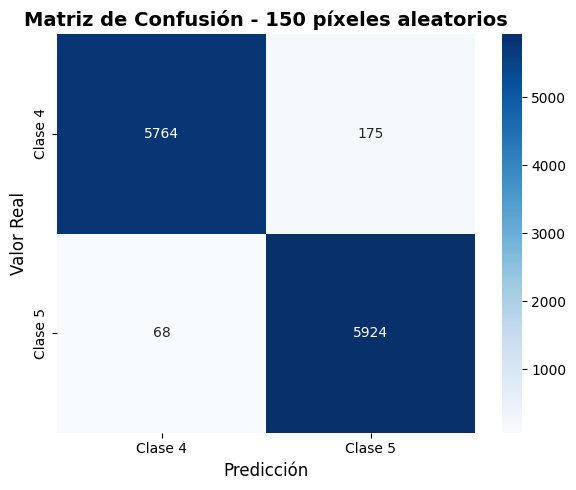

In [196]:
# =============================================================================
# EJECUCIÓN PRINCIPAL
# =============================================================================

array_n_pixeles = generar_puntos_logaritmicos(3, 150, 20)


df_resultados, matrices_confusion = ejecutar_n_atributos(
    X_train, X_test, y_train, y_test,
    array_n_pixeles, k_vecinos=10, repeticiones_estadisticas=2
)

# Obtener la última configuración probada
ultimo_n_pixeles = array_n_pixeles[-1]
matriz_data = matrices_confusion[ultimo_n_pixeles]

# Crear el gráfico de la matriz de confusión
plt.figure(figsize=(6, 5))

sns.heatmap(matriz_data['matriz_confusion'], 
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['Clase 4', 'Clase 5'], 
            yticklabels=['Clase 4', 'Clase 5'])

plt.title(f'Matriz de Confusión - {ultimo_n_pixeles} píxeles aleatorios', fontsize=14, fontweight='bold')
plt.xlabel('Predicción', fontsize=12)
plt.ylabel('Valor Real', fontsize=12)

plt.tight_layout()
plt.show()




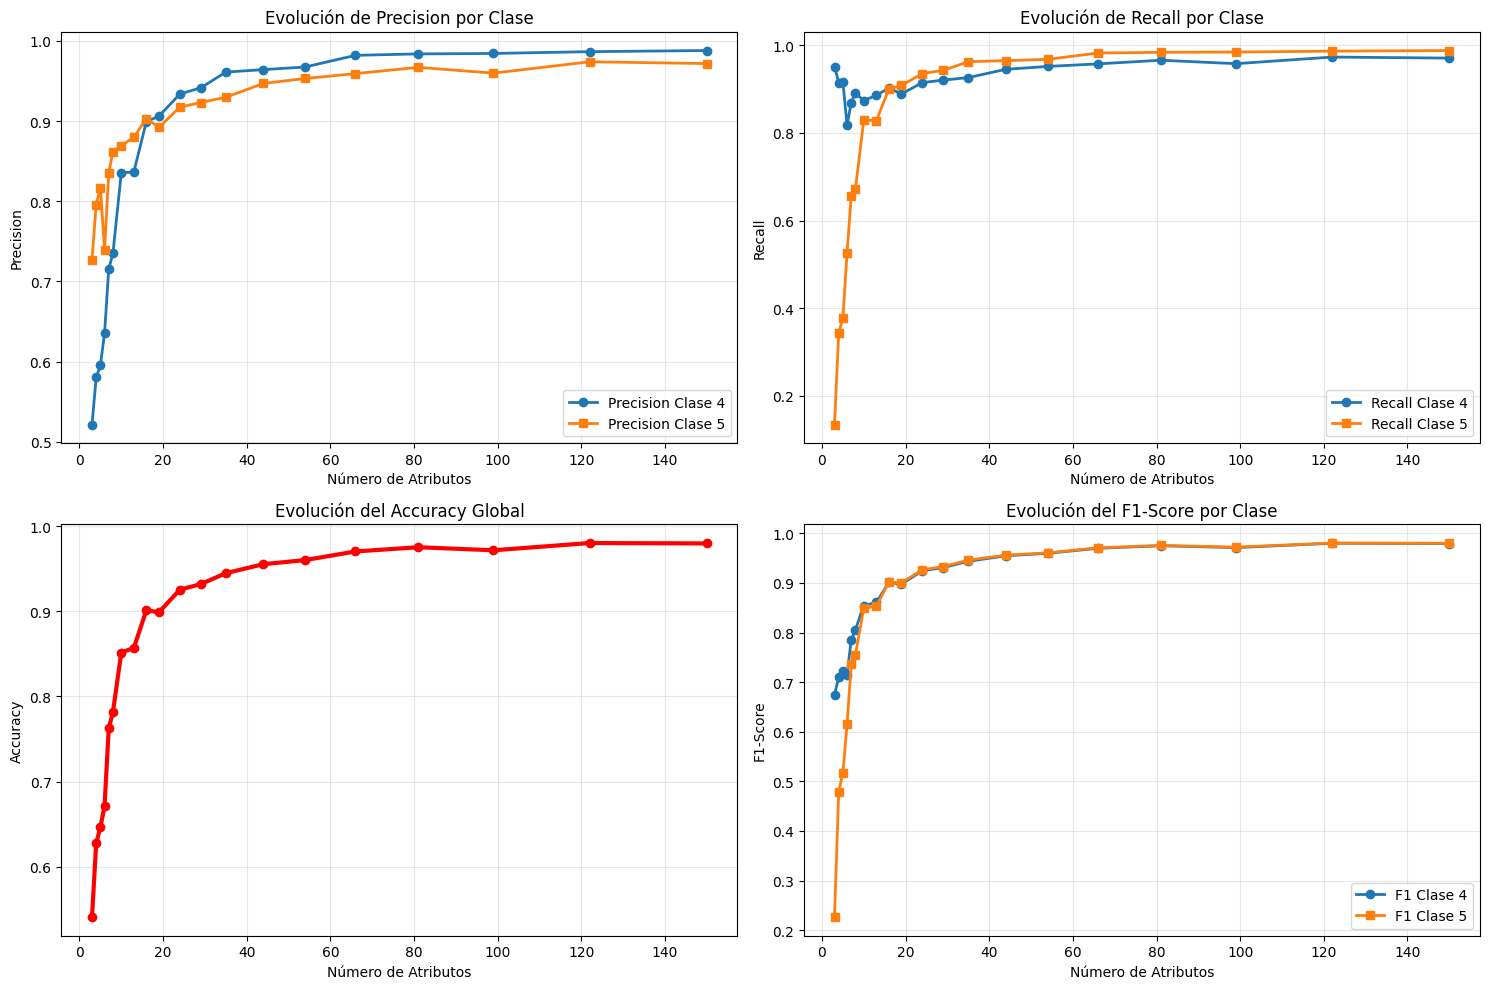

In [197]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Convertir results a DataFrame
df_results = df_resultados

# Crear subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Precision por clase
axes[0,0].plot(df_results['n_atributos'], df_results['presicion_4'], 
               'o-', label='Precision Clase 4', linewidth=2)
axes[0,0].plot(df_results['n_atributos'], df_results['precision_5'], 
               's-', label='Precision Clase 5', linewidth=2)
axes[0,0].set_xlabel('Número de Atributos')
axes[0,0].set_ylabel('Precision')
axes[0,0].set_title('Evolución de Precision por Clase')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Recall por clase
axes[0,1].plot(df_results['n_atributos'], df_results['recall_4'], 
               'o-', label='Recall Clase 4', linewidth=2)
axes[0,1].plot(df_results['n_atributos'], df_results['recall_5'], 
               's-', label='Recall Clase 5', linewidth=2)
axes[0,1].set_xlabel('Número de Atributos')
axes[0,1].set_ylabel('Recall')
axes[0,1].set_title('Evolución de Recall por Clase')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Accuracy global
axes[1,0].plot(df_results['n_atributos'], df_results['accuracy'], 
               'o-', color='red', linewidth=3, label='Accuracy')
axes[1,0].set_xlabel('Número de Atributos')
axes[1,0].set_ylabel('Accuracy')
axes[1,0].set_title('Evolución del Accuracy Global')
axes[1,0].grid(True, alpha=0.3)

# F1-Score por clase (calculado)
df_results['f1_4'] = 2 * (df_results['presicion_4'] * df_results['recall_4']) / (df_results['presicion_4'] + df_results['recall_4'])
df_results['f1_5'] = 2 * (df_results['precision_5'] * df_results['recall_5']) / (df_results['precision_5'] + df_results['recall_5'])

axes[1,1].plot(df_results['n_atributos'], df_results['f1_4'], 
               'o-', label='F1 Clase 4', linewidth=2)
axes[1,1].plot(df_results['n_atributos'], df_results['f1_5'], 
               's-', label='F1 Clase 5', linewidth=2)
axes[1,1].set_xlabel('Número de Atributos')
axes[1,1].set_ylabel('F1-Score')
axes[1,1].set_title('Evolución del F1-Score por Clase')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Analisis Contornos

In [198]:
# Definir los tamaños de recorte a probar
tamanos_recorte = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]  # Hasta imagen 2x2

# Ejecutar el análisis
df_recortes = entrenar_con_recortes(X_train, X_test, y_train, y_test, tamanos_recorte)

# Mostrar resultados
print("\n📊 RESULTADOS POR TAMAÑO DE RECORTE:")
print("=" * 50)
print(df_recortes[['recorte_bordes', 'tamaño_imagen', 'total_pixeles', 'accuracy']].round(4))

Tamaños recorte: 100%|██████████| 14/14 [00:17<00:00,  1.23s/it]


📊 RESULTADOS POR TAMAÑO DE RECORTE:
    recorte_bordes tamaño_imagen  total_pixeles  accuracy
0                0         28x28            784    0.9890
1                1         26x26            676    0.9887
2                2         24x24            576    0.9886
3                3         22x22            484    0.9877
4                4         20x20            400    0.9844
5                5         18x18            324    0.9824
6                6         16x16            256    0.9778
7                7         14x14            196    0.9705
8                8         12x12            144    0.9609
9                9         10x10            100    0.9485
10              10           8x8             64    0.9271
11              11           6x6             36    0.8858
12              12           4x4             16    0.6315
13              13           2x2              4    0.5596


C:\Users\User\AppData\Local\Temp\ipykernel_17952\4212889942.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=11)


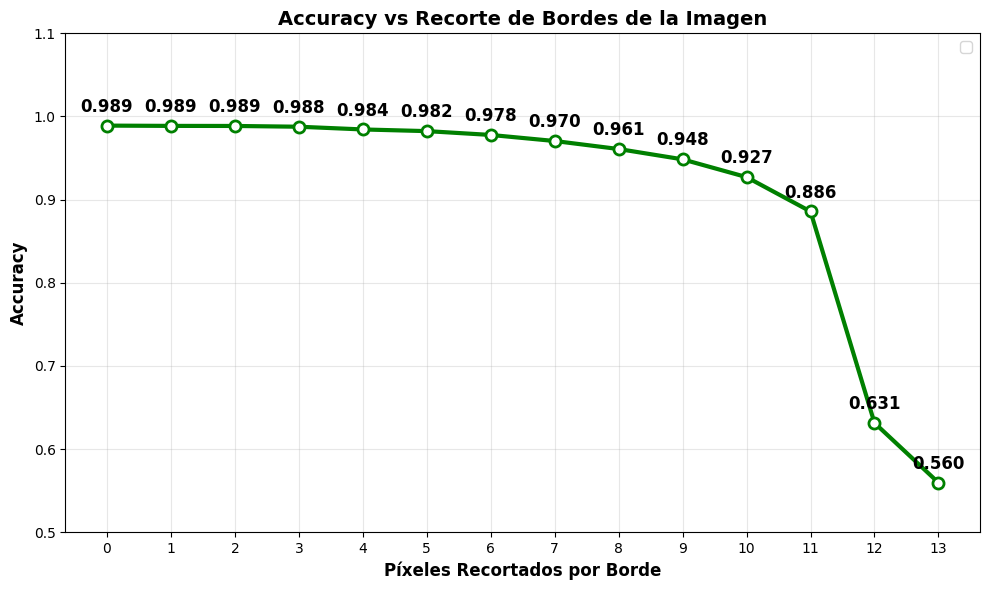

In [199]:
# Gráfico simplificado: Solo píxeles recortados vs accuracy
plt.figure(figsize=(10, 6))

plt.plot(df_recortes['recorte_bordes'], df_recortes['accuracy'], 'o-', 
         linewidth=3, markersize=8, color='green', markerfacecolor='white', markeredgewidth=2)

plt.xlabel('Píxeles Recortados por Borde', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
plt.ylim(0.5, 1.1)

# Configurar el eje X para mostrar todos los números
plt.xticks(df_recortes['recorte_bordes'])  # Esto fuerza a mostrar todos los valores

plt.title('Accuracy vs Recorte de Bordes de la Imagen', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Añadir anotaciones de valores
for i, row in df_recortes.iterrows():
    plt.annotate(f"{row['accuracy']:.3f}", 
                (row['recorte_bordes'], row['accuracy']),
                textcoords="offset points", xytext=(0,10), 
                ha='center', fontsize=12, fontweight='bold')

plt.legend(fontsize=11)
plt.tight_layout()
plt.show()



In [200]:

grosores_borde = [1, 2, 3, 4, 5, 6,7,8,9,10,11,12,13,14]
df_bordes = entrenar_con_bordes(X_train, X_test, y_train, y_test, grosores_borde)

Grosor bordes: 100%|██████████| 14/14 [02:03<00:00,  8.79s/it]


C:\Users\User\AppData\Local\Temp\ipykernel_17952\2960696313.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=11)


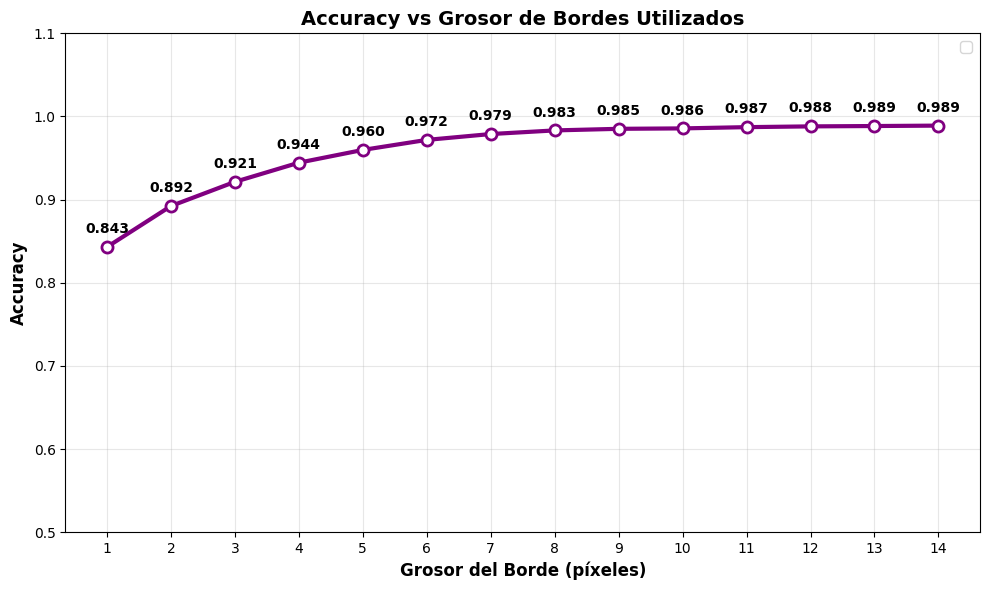

In [201]:
# Gráfico simplificado: Grosor de bordes vs accuracy
plt.figure(figsize=(10, 6))

plt.plot(df_bordes['grosor_borde'], df_bordes['accuracy'], 'o-', 
         linewidth=3, markersize=8, color='purple', markerfacecolor='white', markeredgewidth=2)

plt.xlabel('Grosor del Borde (píxeles)', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
plt.ylim(0.5, 1.1)  
# Configurar el eje X para mostrar todos los números
plt.xticks(df_bordes['grosor_borde'])

plt.title('Accuracy vs Grosor de Bordes Utilizados', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Añadir anotaciones de valores
for i, row in df_bordes.iterrows():
    plt.annotate(f"{row['accuracy']:.3f}", 
                (row['grosor_borde'], row['accuracy']),
                textcoords="offset points", xytext=(0,10), 
                ha='center', fontsize=10, fontweight='bold')

plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


# Analisis 3

🚀 Iniciando búsqueda de profundidad óptima...


Probando profundidades:   0%|          | 0/10 [00:00<?, ?depth/s]

📊 Evaluando profundidad 1...


Probando profundidades:  10%|█         | 1/10 [00:06<00:56,  6.31s/depth]

📊 Evaluando profundidad 2...


...

📊 Evaluando profundidad 10...


Probando profundidades: 100%|██████████| 10/10 [01:29<00:00,  8.98s/depth]


 Búsqueda de profundidades completada!

 Mejor profundidad encontrada: 10
 Mejor accuracy: 0.6956

🔧 Entrenando modelo final...


Entrenando modelo final: 100%|██████████| 100/100 [00:19<00:00,  5.06it/s]


 Modelo final entrenado!

🎯 Realizando predicciones...

 Generando visualizaciones...


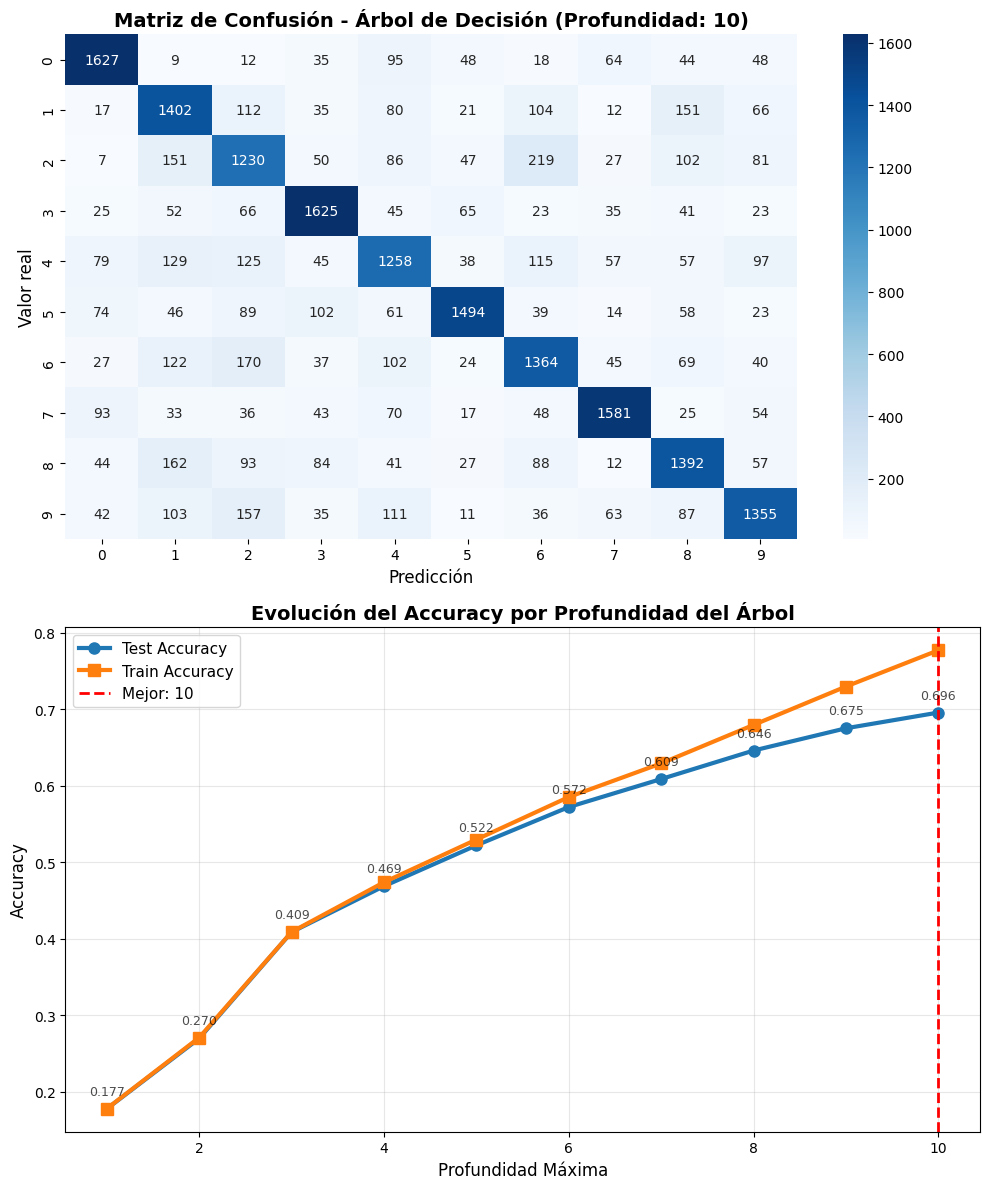


 REPORTE DE CLASIFICACIÓN FINAL
              precision    recall  f1-score   support

           0       0.80      0.81      0.81      2000
           1       0.63      0.70      0.67      2000
           2       0.59      0.61      0.60      2000
           3       0.78      0.81      0.79      2000
           4       0.65      0.63      0.64      2000
           5       0.83      0.75      0.79      2000
           6       0.66      0.68      0.67      2000
           7       0.83      0.79      0.81      2000
           8       0.69      0.70      0.69      2000
           9       0.73      0.68      0.70      2000

    accuracy                           0.72     20000
   macro avg       0.72      0.72      0.72     20000
weighted avg       0.72      0.72      0.72     20000


 RESUMEN POR PROFUNDIDAD
   Profundidad  1: Test Acc = 0.1775, Train Acc = 0.1777, F1 = 0.0622
   Profundidad  2: Test Acc = 0.2695, Train Acc = 0.2707, F1 = 0.1681
   Profundidad  3: Test Acc = 0.4085, Trai

In [202]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm

# Preparación de datos
n_muestras = 5000
muestras_train_tree = map_caracters.groupby('label').sample(n=n_muestras)
muestras_val_tree = map_caracters.loc[~map_caracters.index.isin(muestras_train_tree.index)]

X_train_tree = muestras_train_tree.drop('label', axis=1).reset_index(drop=True)
y_train_tree = muestras_train_tree.loc[:, 'label'].reset_index(drop=True)

X_val_tree = muestras_val_tree.drop('label', axis=1).reset_index(drop=True)
y_val_tree = muestras_val_tree.loc[:, 'label'].reset_index(drop=True)

print("🚀 Iniciando búsqueda de profundidad óptima...")

# Búsqueda de profundidad óptima con barra de progreso
metrics = []
metrics_mean = []

# Barra de progreso para las profundidades
for i in tqdm(range(1, 11), desc="Probando profundidades", unit="depth"):
    dtc = DecisionTreeClassifier(max_depth=i, random_state=42)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    tqdm.write(f"📊 Evaluando profundidad {i}...")
    
    metricas = cross_validate(
        dtc, X_train_tree, y_train_tree, cv=cv,
        scoring=['accuracy', 'precision_macro', 'recall_macro', 'f1_macro'],
        return_train_score=True,
        n_jobs=-1
    )
    
    df = pd.DataFrame(metricas)
    metrics.append(df)
    metrics_mean.append(df.mean())

print(" Búsqueda de profundidades completada!")

# Crear DataFrame con resultados
resultados_df = pd.DataFrame(metrics_mean)
resultados_df['max_depth'] = range(1, 11)

# Mostrar mejores resultados
mejor_profundidad = resultados_df['test_accuracy'].idxmax() + 1
print(f"\n Mejor profundidad encontrada: {mejor_profundidad}")
print(f" Mejor accuracy: {resultados_df.loc[mejor_profundidad-1, 'test_accuracy']:.4f}")

# Entrenar modelo final
print("\n🔧 Entrenando modelo final...")
dtc_final = DecisionTreeClassifier(max_depth=mejor_profundidad, criterion='entropy', random_state=42)

with tqdm(total=100, desc="Entrenando modelo final") as pbar:
    dtc_final.fit(X_train_tree, y_train_tree)
    pbar.update(100)

print(" Modelo final entrenado!")

# Predicciones
print("\n🎯 Realizando predicciones...")
y_pred_tree = dtc_final.predict(X_val_tree)

# VISUALIZACIÓN EN FORMATO VERTICAL (2,1)
print("\n Generando visualizaciones...")

# Crear figura con 2 subplots verticales
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))

# SUBPLOT 1: Matriz de confusión (arriba)
matriz_confusion = confusion_matrix(y_val_tree, y_pred_tree)
sns.heatmap(matriz_confusion, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=range(10), yticklabels=range(10))
ax1.set_xlabel("Predicción", fontsize=12)
ax1.set_ylabel("Valor real", fontsize=12)
ax1.set_title(f"Matriz de Confusión - Árbol de Decisión (Profundidad: {mejor_profundidad})", 
              fontsize=14, fontweight='bold')

# SUBPLOT 2: Evolución de métricas por profundidad (abajo)
ax2.plot(resultados_df['max_depth'], resultados_df['test_accuracy'], 'o-', 
         label='Test Accuracy', linewidth=3, markersize=8)
ax2.plot(resultados_df['max_depth'], resultados_df['train_accuracy'], 's-', 
         label='Train Accuracy', linewidth=3, markersize=8)
ax2.axvline(x=mejor_profundidad, color='red', linestyle='--', 
            linewidth=2, label=f'Mejor: {mejor_profundidad}')
ax2.set_xlabel('Profundidad Máxima', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Evolución del Accuracy por Profundidad del Árbol', 
              fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

# Añadir anotaciones de valores en el gráfico de accuracy
for i, row in resultados_df.iterrows():
    ax2.annotate(f"{row['test_accuracy']:.3f}", 
                (row['max_depth'], row['test_accuracy']),
                textcoords="offset points", xytext=(0,10), 
                ha='center', fontsize=9, alpha=0.7)

plt.tight_layout()
plt.show()

# Reporte de clasificación
print("\n" + "="*60)
print(" REPORTE DE CLASIFICACIÓN FINAL")
print("="*60)
reporte_tree = classification_report(y_val_tree, y_pred_tree)
print(reporte_tree)

# Resumen de resultados por profundidad
print("\n" + "="*60)
print(" RESUMEN POR PROFUNDIDAD")
print("="*60)
for i, row in resultados_df.iterrows():
    marca = "" if (i + 1) == mejor_profundidad else "  "
    print(f"{marca} Profundidad {i+1:2d}: "
          f"Test Acc = {row['test_accuracy']:.4f}, "
          f"Train Acc = {row['train_accuracy']:.4f}, "
          f"F1 = {row['test_f1_macro']:.4f}")

# Estadísticas adicionales de la matriz de confusión
print("\n" + "="*60)
print(" ANÁLISIS DE LA MATRIZ DE CONFUSIÓN")
print("="*60)
total_muestras = matriz_confusion.sum()
correctas = matriz_confusion.diagonal().sum()
accuracy_manual = correctas / total_muestras

print(f"Total de muestras: {total_muestras}")
print(f"Predicciones correctas: {correctas}")
print(f"Accuracy desde matriz: {accuracy_manual:.4f}")
print(f"Mejor profundidad: {mejor_profundidad}")

# Mostrar clases con más errores
errores_por_clase = []
for i in range(10):
    total_clase = matriz_confusion[i].sum()
    correctas_clase = matriz_confusion[i, i]
    errores_clase = total_clase - correctas_clase
    tasa_error = errores_clase / total_clase if total_clase > 0 else 0
    errores_por_clase.append((i, tasa_error, errores_clase))

# Ordenar por tasa de error descendente
errores_por_clase.sort(key=lambda x: x[1], reverse=True)

print(f"\n CLASES CON MÁS ERRORES:")
for clase, tasa_error, num_errores in errores_por_clase[:3]:
    print(f"  Clase {clase}: {tasa_error:.2%} de error ({num_errores} errores)")